# Data Cleaning and Exploratory Data Analysis

This notebook documents the Phase 1 data preparation and initial operational analysis for the AI-Augmented Customer Support Operations Analytics project.

**Dataset:** Multilingual Customer Support Tickets (Kaggle)  
**Scope:** English-language tickets only  
**Status:** Executed against the local cleaned dataset

## tl;dr

- The cleaned English-language dataset contains **16,338 tickets**, reduced from 28,587 source rows after applying the language filter and text-quality checks.
- The workload is concentrated in **Incident** tickets (6,571; 40.2%), followed by **Request** tickets (4,665; 28.6%).
- **Technical Support** is the largest routing queue (4,737; 29.0%), so it is an important area to examine when designing AI-assisted triage.
- Priorities are concentrated in **medium** (6,618; 40.5%) and **high** (6,346; 38.8%), reinforcing the need to measure routing errors rather than optimise for automation rate alone.
- No duplicate ticket texts remain after cleaning. The median combined subject-and-body length is **416 characters**, which is suitable for concise LLM classification prompts.

## Context and Methods

The source dataset is synthetic but designed to resemble customer support tickets. It is used to demonstrate an analysis methodology that can transfer to production ticket data. The cleaning pipeline combines `subject` and `body` into a single `ticket_text` field, filters to English records, removes empty ticket text, standardises label names, and removes duplicates.

### Key Assumptions

- Existing dataset labels are treated as the comparison baseline for later LLM validation.
- The queue label is used as the operational department or routing destination.
- This notebook reports observed distributions only. Any later time or cost saving estimates will be labelled as simulations.

## Data

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CLEANED_FILE = PROJECT_ROOT / 'data' / 'processed' / 'tickets_cleaned.csv'
SUMMARY_FILE = PROJECT_ROOT / 'data' / 'processed' / 'cleaning_summary.json'

sns.set_theme(style='whitegrid', context='notebook')

In [2]:
if not CLEANED_FILE.exists() or not SUMMARY_FILE.exists():
    raise FileNotFoundError(
        'Cleaned data is missing. Run src.run_pipeline with the Kaggle CSV before executing this notebook.'
    )

tickets = pd.read_csv(CLEANED_FILE)
cleaning_summary = json.loads(SUMMARY_FILE.read_text(encoding='utf-8'))

print(f'Loaded {len(tickets):,} cleaned tickets from: {CLEANED_FILE.name}')
display(tickets.head(3))

Loaded 16,338 cleaned tickets from: tickets_cleaned.csv


,ticket_id,subject,body,answer,actual_category,actual_department,actual_priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,ticket_text
0,1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,"Account Disruption Dear Customer Support Team,..."
1,2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,Query About Smart Home System Integration Feat...
2,3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,Inquiry Regarding Invoice Details Dear Custome...


In [3]:
cleaning_audit = pd.DataFrame(
    {
        'metric': [
            'Source rows',
            'Rows after English-language filter',
            'Rows after text-quality filter',
            'Final cleaned rows',
            'Rows removed'
        ],
        'value': [
            cleaning_summary['starting_rows'],
            cleaning_summary['rows_after_language_filter'],
            cleaning_summary['rows_after_text_filter'],
            cleaning_summary['final_rows'],
            cleaning_summary['removed_rows_total']
        ]
    }
)
display(cleaning_audit)

,metric,value
0,Source rows,28587
1,Rows after English-language filter,16338
2,Rows after text-quality filter,16338
3,Final cleaned rows,16338
4,Rows removed,12249


In [4]:
quality_checks = pd.DataFrame(
    {
        'check': [
            'Duplicate ticket text',
            'Missing category label',
            'Missing department label',
            'Missing priority label',
            'Median ticket text length (characters)'
        ],
        'result': [
            tickets['ticket_text'].duplicated().sum(),
            tickets['actual_category'].isna().sum(),
            tickets['actual_department'].isna().sum(),
            tickets['actual_priority'].isna().sum(),
            round(tickets['ticket_text'].str.len().median(), 1)
        ]
    }
)
display(quality_checks)

,check,result
0,Duplicate ticket text,0.0
1,Missing category label,0.0
2,Missing department label,0.0
3,Missing priority label,0.0
4,Median ticket text length (characters),416.0


## Results

In [5]:
def distribution_table(data: pd.DataFrame, column: str, label: str) -> pd.DataFrame:
    table = (
        data[column]
        .fillna('Missing')
        .value_counts()
        .rename_axis(label)
        .reset_index(name='ticket_count')
    )
    table['ticket_share'] = table['ticket_count'] / table['ticket_count'].sum()
    return table

category_distribution = distribution_table(tickets, 'actual_category', 'category')
department_distribution = distribution_table(tickets, 'actual_department', 'department')
priority_distribution = distribution_table(tickets, 'actual_priority', 'priority')

display(category_distribution)

,category,ticket_count,ticket_share
0,Incident,6571,0.402191
1,Request,4665,0.285531
2,Problem,3397,0.207920
3,Change,1705,0.104358


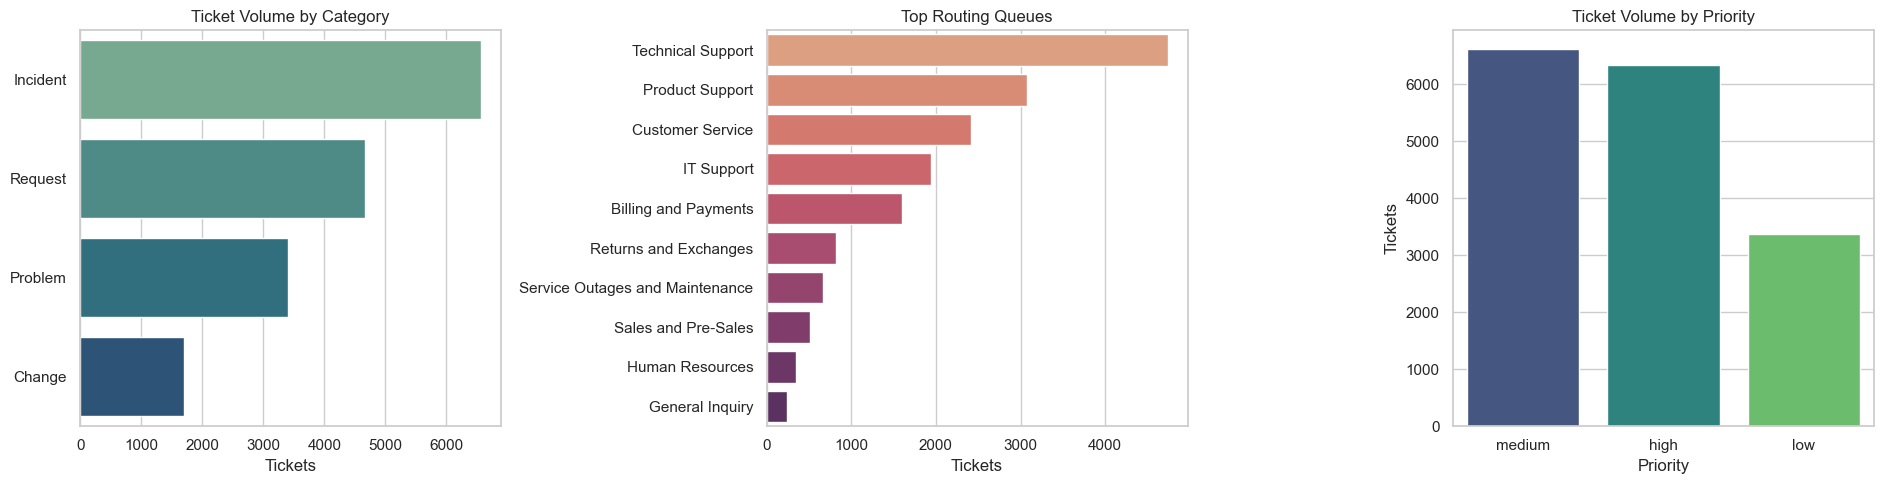

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.barplot(data=category_distribution, x='ticket_count', y='category', hue='category', legend=False, ax=axes[0], palette='crest')
axes[0].set_title('Ticket Volume by Category')
axes[0].set_xlabel('Tickets')
axes[0].set_ylabel('')

department_plot = department_distribution.head(10)
sns.barplot(data=department_plot, x='ticket_count', y='department', hue='department', legend=False, ax=axes[1], palette='flare')
axes[1].set_title('Top Routing Queues')
axes[1].set_xlabel('Tickets')
axes[1].set_ylabel('')

sns.barplot(data=priority_distribution, x='priority', y='ticket_count', hue='priority', legend=False, ax=axes[2], palette='viridis')
axes[2].set_title('Ticket Volume by Priority')
axes[2].set_xlabel('Priority')
axes[2].set_ylabel('Tickets')

plt.tight_layout()
plt.show()

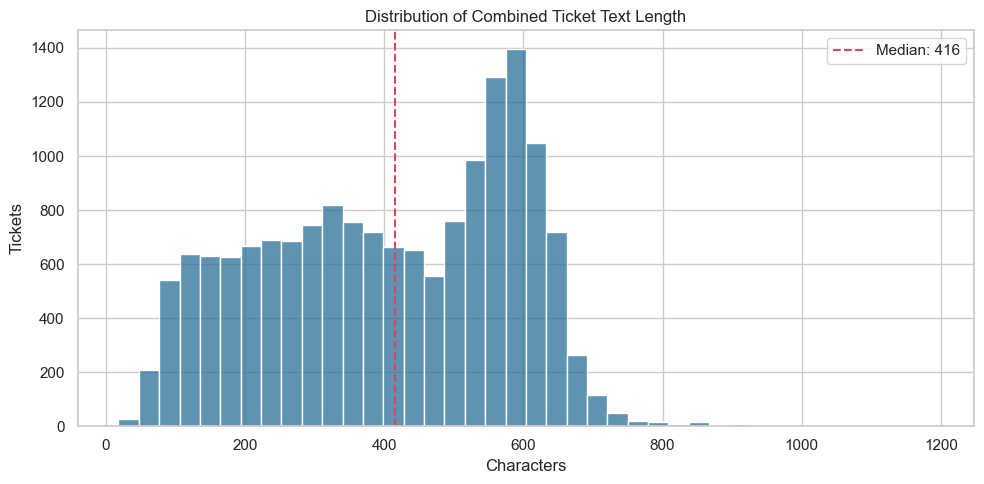

,subject,body,ticket_text
14848,Query on Data Analytics Tools for Investment O...,"Dear Customer Support, I am inquiring about th...",Query on Data Analytics Tools for Investment O...
10388,Problems with Connection,Customers are facing occasional connectivity p...,Problems with Connection Customers are facing ...
12919,NaN,"Hello Customer Support, I am inquiring about o...","Hello Customer Support, I am inquiring about o..."


In [7]:
ticket_lengths = tickets['ticket_text'].str.len()

plt.figure(figsize=(10, 5))
sns.histplot(ticket_lengths, bins=40, color='#2a6f97')
plt.axvline(ticket_lengths.median(), color='#d1495b', linestyle='--', label=f'Median: {ticket_lengths.median():.0f}')
plt.title('Distribution of Combined Ticket Text Length')
plt.xlabel('Characters')
plt.ylabel('Tickets')
plt.legend()
plt.tight_layout()
plt.show()

display(tickets[['subject', 'body', 'ticket_text']].sample(3, random_state=42))

## Takeaways

The cleaned data provides a stable baseline for the next phase. Ticket demand is not evenly distributed: Incident and Request work together account for 68.8% of the observed volume, while Technical Support is the largest routing queue. The later AI-routing analysis should therefore report both overall performance and category-level empirical accuracy, rather than allowing a strong result in a high-volume class to hide weak routing performance elsewhere.

The next notebook will classify the fixed 500-ticket stratified sample with Gemini using a Free Tier API key, then retain the raw predictions for transparent validation against the dataset labels.